# Dataset en espiral y clasificadores bayesianos

Este notebook genera un dataset 2D tipo espiral con columnas `x1`, `x2`, `label`, y compara cinco clasificadores:

1. Naive Bayes gaussiano
2. K-nearest neighbours
3. Clasificador que usa solo los priors
4. Bayesiano con una sola gaussiana por clase
5. Bayesiano con mezcla de gaussianas por clase

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.stats import multivariate_normal

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

In [2]:
def make_spiral_dataset(n_points_per_class=150, noise=0.12, rotations=2.1, random_state=42):
    rng = np.random.default_rng(random_state)
    theta = np.linspace(0.25, rotations * 2 * np.pi, n_points_per_class)
    radius = theta

    x_a = radius * np.cos(theta) + rng.normal(0, noise, n_points_per_class)
    y_a = radius * np.sin(theta) + rng.normal(0, noise, n_points_per_class)

    theta_b = theta + np.pi
    x_b = radius * np.cos(theta_b) + rng.normal(0, noise, n_points_per_class)
    y_b = radius * np.sin(theta_b) + rng.normal(0, noise, n_points_per_class)

    X = np.vstack([
        np.column_stack([x_a, y_a]),
        np.column_stack([x_b, y_b])
    ])
    y = np.array([0] * n_points_per_class + [1] * n_points_per_class)

    X = X / np.max(np.abs(X))

    df = pd.DataFrame(X, columns=["x1", "x2"])
    df["label"] = y
    return df

In [3]:
df = make_spiral_dataset(n_points_per_class=140, noise=0.018, rotations=2.15, random_state=7)
df.head()

,x1,x2,label
0,0.019241,0.006483,0
1,0.026239,0.008511,0
2,0.031270,0.014863,0
3,0.035336,0.020620,0
4,0.039835,0.028720,0


In [4]:
class_means = df.groupby("label")[["x1", "x2"]].mean().reset_index()
class_means

,label,x1,x2
0,0,0.064396,-0.039483
1,1,-0.064599,0.038861


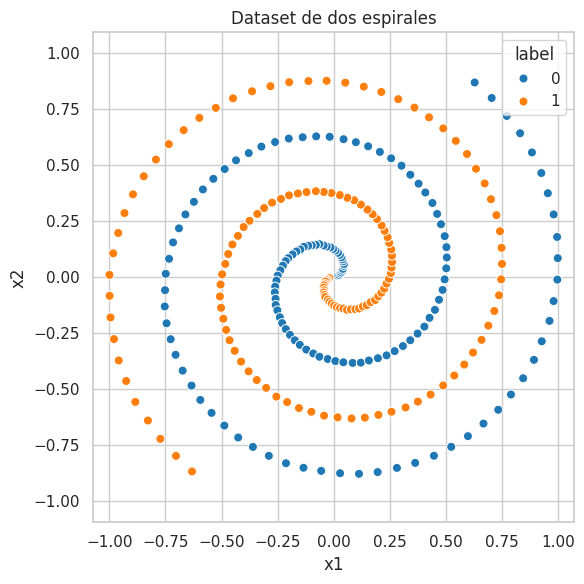

In [5]:
colors = {0: "#1f77b4", 1: "#ff7f0e"}

plt.figure(figsize=(6, 6))
if sns is not None:
    sns.set_theme(style="whitegrid")
    sns.scatterplot(
        data=df,
        x="x1",
        y="x2",
        hue="label",
        palette=[colors[0], colors[1]],
        s=42,
        edgecolor="white",
        linewidth=0.7
    )
else:
    for label, color in colors.items():
        subset = df[df["label"] == label]
        plt.scatter(subset["x1"], subset["x2"], s=42, c=color, edgecolors="white", linewidths=0.7, label=label)
    plt.grid(True, alpha=0.25)
plt.title("Dataset de dos espirales")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend(title="label")
plt.tight_layout()
plt.show()

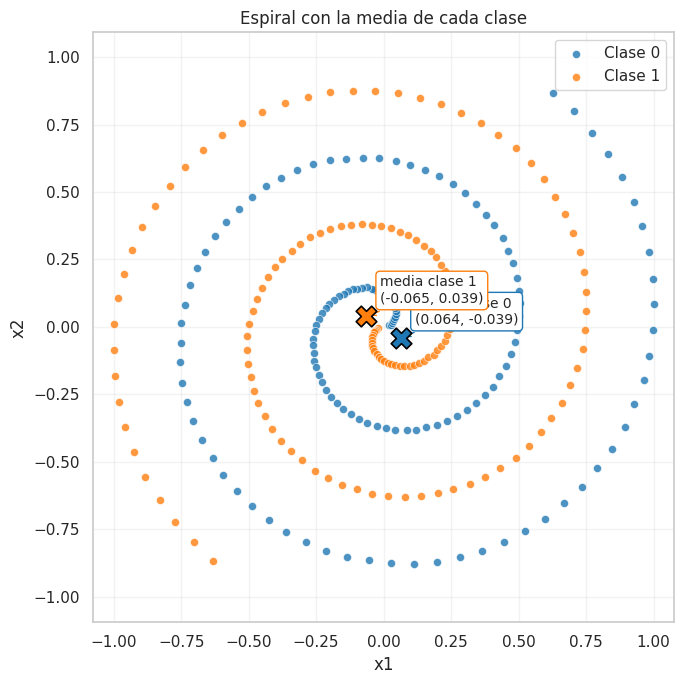

In [6]:
plt.figure(figsize=(7, 7))
for label, color in colors.items():
    subset = df[df["label"] == label]
    plt.scatter(subset["x1"], subset["x2"], s=34, c=color, alpha=0.8, edgecolors="white", linewidths=0.5, label=f"Clase {label}")

for _, row in class_means.iterrows():
    label = int(row["label"])
    plt.scatter(row["x1"], row["x2"], s=220, c=colors[label], marker="X", edgecolors="black", linewidths=1.2, zorder=5)
    plt.annotate(
        f"media clase {label}\n({row['x1']:.3f}, {row['x2']:.3f})",
        (row["x1"], row["x2"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[label]),
        arrowprops=dict(arrowstyle="->", color=colors[label]),
    )

plt.title("Espiral con la media de cada clase")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# for i, label in enumerate(sorted(df["label"].unique())):
#     subset = df[df["label"] == label]
#     mean_row = class_means[class_means["label"] == label].iloc[0]
#     ax[i].scatter(subset["x1"], subset["x2"], s=32, c=colors[label], alpha=0.85)
#     ax[i].scatter(mean_row["x1"], mean_row["x2"], s=240, c="gold", marker="X", edgecolors="black", linewidths=1.2)
#     ax[i].axvline(mean_row["x1"], color="black", linestyle="--", alpha=0.6)
#     ax[i].axhline(mean_row["x2"], color="black", linestyle="--", alpha=0.6)
#     ax[i].set_title(f"Clase {label}")
#     ax[i].set_xlabel("x1")
#     ax[i].grid(True, alpha=0.25)
#     ax[i].set_aspect("equal", adjustable="box")

# ax[0].set_ylabel("x2")
# fig.suptitle("Media por clase vista por separado", y=1.02)
# plt.tight_layout()
# plt.show()

## Modelos

In [8]:
X = df[["x1", "x2"]].to_numpy()
y = df["label"].to_numpy()
classes = np.unique(y)

def accuracy_score(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def make_grid(X, steps=300, padding=0.12):
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    dx = (x_max - x_min) * padding
    dy = (y_max - y_min) * padding

    xx, yy = np.meshgrid(
        np.linspace(x_min - dx, x_max + dx, steps),
        np.linspace(y_min - dy, y_max + dy, steps),
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    return xx, yy, grid

def ellipse_from_cov(cov):
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 1e-8)
    return vals, vecs

In [9]:
def fit_prior_only(y):
    priors = np.bincount(y) / len(y)
    return {"priors": priors, "majority": int(np.argmax(priors))}

def predict_prior_only(model, X_query):
    return np.full(len(X_query), model["majority"], dtype=int)

def fit_gaussian_nb(X, y, var_smoothing=1e-4):
    priors = np.bincount(y) / len(y)
    means = []
    variances = []
    for cls in classes:
        Xc = X[y == cls]
        means.append(Xc.mean(axis=0))
        variances.append(Xc.var(axis=0) + var_smoothing)
    return {"priors": priors, "means": np.vstack(means), "variances": np.vstack(variances)}

def gaussian_nb_log_posteriors(model, X_query):
    logs = []
    for idx, cls in enumerate(classes):
        mu = model["means"][idx]
        var = model["variances"][idx]
        log_det = np.sum(np.log(2 * np.pi * var))
        quad = np.sum(((X_query - mu) ** 2) / var, axis=1)
        logs.append(np.log(model["priors"][cls]) - 0.5 * (log_det + quad))
    return np.column_stack(logs)

def predict_gaussian_nb(model, X_query):
    return classes[np.argmax(gaussian_nb_log_posteriors(model, X_query), axis=1)]

def fit_knn(X, y, k=7):
    return {"X": X, "y": y, "k": k}

def predict_knn(model, X_query):
    distances = np.sqrt(((X_query[:, None, :] - model["X"][None, :, :]) ** 2).sum(axis=2))
    nn_idx = np.argpartition(distances, kth=model["k"] - 1, axis=1)[:, :model["k"]]
    votes = model["y"][nn_idx]
    return (votes.mean(axis=1) >= 0.5).astype(int)

def fit_single_gaussian(X, y, reg=1e-3):
    priors = np.bincount(y) / len(y)
    params = []
    for cls in classes:
        Xc = X[y == cls]
        mean = Xc.mean(axis=0)
        cov = np.cov(Xc.T) + reg * np.eye(X.shape[1])
        params.append({"mean": mean, "cov": cov})
    return {"priors": priors, "params": params}

def single_gaussian_log_posteriors(model, X_query):
    logs = []
    for idx, cls in enumerate(classes):
        mean = model["params"][idx]["mean"]
        cov = model["params"][idx]["cov"]
        rv = multivariate_normal(mean=mean, cov=cov, allow_singular=False)
        logs.append(np.log(model["priors"][cls]) + rv.logpdf(X_query))
    return np.column_stack(logs)

def predict_single_gaussian(model, X_query):
    return classes[np.argmax(single_gaussian_log_posteriors(model, X_query), axis=1)]

In [10]:
def fit_gmm_em(X, n_components=3, reg=1e-4, max_iter=150, tol=1e-5, random_state=0):
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    chosen = rng.choice(n_samples, size=n_components, replace=False)
    means = X[chosen].copy()
    base_cov = np.cov(X.T) + reg * np.eye(n_features)
    covs = np.array([base_cov.copy() for _ in range(n_components)])
    weights = np.full(n_components, 1.0 / n_components)
    prev_ll = -np.inf

    for _ in range(max_iter):
        log_resp = []
        for k in range(n_components):
            rv = multivariate_normal(mean=means[k], cov=covs[k], allow_singular=False)
            log_resp.append(np.log(weights[k] + 1e-12) + rv.logpdf(X))
        log_resp = np.column_stack(log_resp)
        log_total = logsumexp(log_resp, axis=1, keepdims=True)
        responsibilities = np.exp(log_resp - log_total)
        ll = log_total.sum()

        Nk = responsibilities.sum(axis=0) + 1e-12
        weights = Nk / n_samples
        means = (responsibilities.T @ X) / Nk[:, None]

        new_covs = []
        for k in range(n_components):
            diff = X - means[k]
            cov = (responsibilities[:, k][:, None] * diff).T @ diff / Nk[k]
            cov += reg * np.eye(n_features)
            new_covs.append(cov)
        covs = np.array(new_covs)

        if np.abs(ll - prev_ll) < tol:
            break
        prev_ll = ll

    return {"weights": weights, "means": means, "covs": covs}

def fit_gmm_classifier(X, y, n_components=3, reg=1e-4, max_iter=150, tol=1e-5, random_state=0):
    priors = np.bincount(y) / len(y)
    models = []
    for cls in classes:
        Xc = X[y == cls]
        models.append(fit_gmm_em(Xc, n_components=n_components, reg=reg, max_iter=max_iter, tol=tol, random_state=random_state + int(cls)))
    return {"priors": priors, "models": models}

def gmm_log_density(model, X_query):
    parts = []
    for weight, mean, cov in zip(model["weights"], model["means"], model["covs"]):
        rv = multivariate_normal(mean=mean, cov=cov, allow_singular=False)
        parts.append(np.log(weight + 1e-12) + rv.logpdf(X_query))
    return logsumexp(np.column_stack(parts), axis=1)

def gmm_log_posteriors(model, X_query):
    logs = []
    for idx, cls in enumerate(classes):
        logs.append(np.log(model["priors"][cls]) + gmm_log_density(model["models"][idx], X_query))
    return np.column_stack(logs)

def predict_gmm_classifier(model, X_query):
    return classes[np.argmax(gmm_log_posteriors(model, X_query), axis=1)]

In [11]:
models = {
    "Naive Bayes": {
        "fit": fit_gaussian_nb(X, y),
        "predict": predict_gaussian_nb,
        "log_post": gaussian_nb_log_posteriors,
    },
    "KNN (k=7)": {
        "fit": fit_knn(X, y, k=7),
        "predict": predict_knn,
    },
    "Solo priors": {
        "fit": fit_prior_only(y),
        "predict": predict_prior_only,
    },
    "1 gaussiana / clase": {
        "fit": fit_single_gaussian(X, y, reg=1e-3),
        "predict": predict_single_gaussian,
        "log_post": single_gaussian_log_posteriors,
    },
    "Mezcla de gaussianas": {
        "fit": fit_gmm_classifier(X, y, n_components=3, reg=1e-4, max_iter=180, tol=1e-5, random_state=10),
        "predict": predict_gmm_classifier,
        "log_post": gmm_log_posteriors,
    },
}

metrics = []
for name, info in models.items():
    y_pred = info["predict"](info["fit"], X)
    metrics.append({"modelo": name, "accuracy_entrenamiento": accuracy_score(y, y_pred)})

metrics_df = pd.DataFrame(metrics).sort_values("accuracy_entrenamiento", ascending=False).reset_index(drop=True)
metrics_df

,modelo,accuracy_entrenamiento
0,KNN (k=7),0.992857
1,Mezcla de gaussianas,0.617857
2,1 gaussiana / clase,0.525000
3,Naive Bayes,0.517857
4,Solo priors,0.500000


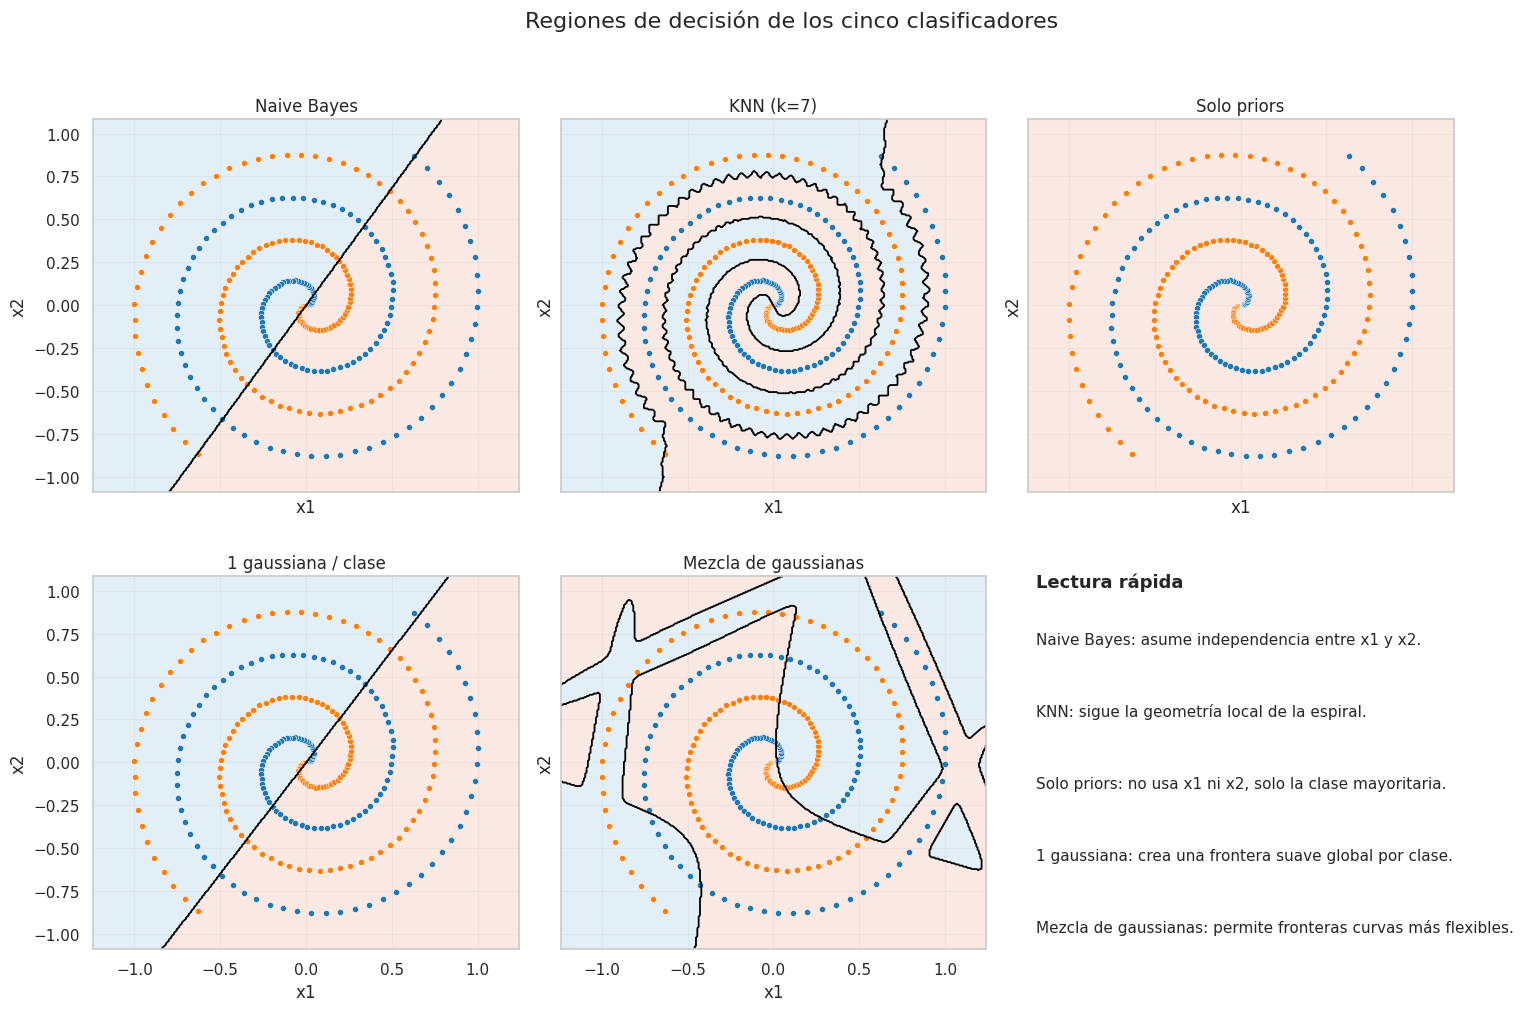

In [12]:
def plot_decision_regions(ax, title, predictor, X, y, xx, yy, grid):
    Z = predictor(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(-0.5, 1.5, 3), cmap=plt.cm.RdBu, alpha=0.18)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.3)
    for cls in classes:
        subset = X[y == cls]
        ax.scatter(subset[:, 0], subset[:, 1], s=20, c=colors[int(cls)], edgecolors="white", linewidths=0.4)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

xx, yy, grid = make_grid(X, steps=320)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, info) in zip(axes, models.items()):
    predictor = lambda points, model=info["fit"], fn=info["predict"]: fn(model, points)
    plot_decision_regions(ax, name, predictor, X, y, xx, yy, grid)

axes[-1].axis("off")
axes[-1].text(0.02, 0.95, "Lectura rápida", transform=axes[-1].transAxes, fontsize=13, fontweight="bold", va="top")
axes[-1].text(0.02, 0.78, "Naive Bayes: asume independencia entre x1 y x2.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.61, "KNN: sigue la geometría local de la espiral.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.44, "Solo priors: no usa x1 ni x2, solo la clase mayoritaria.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.27, "1 gaussiana: crea una frontera suave global por clase.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.10, "Mezcla de gaussianas: permite fronteras curvas más flexibles.", transform=axes[-1].transAxes, fontsize=11)

fig.suptitle("Regiones de decisión de los cinco clasificadores", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Cómo se forma la frontera en los modelos gaussianos

En los clasificadores gaussianos la frontera de decisión sale de igualar los posteriors de las dos clases:

$$\log p(C_0) + \log p(x \mid C_0) = \log p(C_1) + \log p(x \mid C_1)$$

La línea negra que verás abajo es exactamente el conjunto de puntos donde esa diferencia vale cero.

- En **Naive Bayes** la covarianza es diagonal, así que las curvas de densidad quedan alineadas con los ejes.
- En **1 gaussiana por clase** la covarianza es completa, así que las elipses pueden rotar.
- En **mezcla de gaussianas** cada clase es suma de varias gaussianas, por eso la frontera puede doblarse y adaptarse mejor a la espiral.

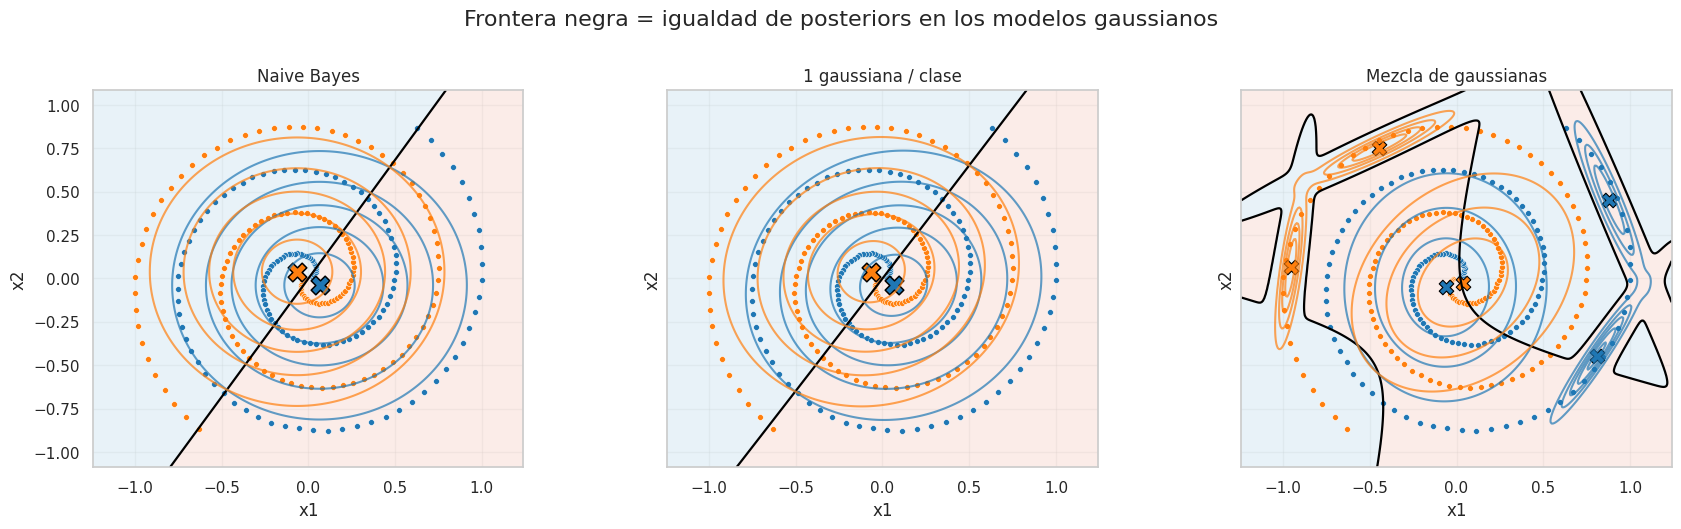

In [13]:
def plot_gaussian_boundary(ax, X, y, xx, yy, grid, log_post_fn, model, title, contour_levels=5):
    log_post = log_post_fn(model, grid)
    diff = (log_post[:, 1] - log_post[:, 0]).reshape(xx.shape)
    pred = (diff >= 0).astype(int)

    ax.contourf(xx, yy, pred, levels=np.linspace(-0.5, 1.5, 3), cmap=plt.cm.RdBu, alpha=0.15)
    ax.contour(xx, yy, diff, levels=[0], colors="black", linewidths=1.6)

    for cls in classes:
        subset = X[y == cls]
        ax.scatter(subset[:, 0], subset[:, 1], s=18, c=colors[int(cls)], edgecolors="white", linewidths=0.4)

    if title == "Naive Bayes":
        for idx, cls in enumerate(classes):
            mean = model["means"][idx]
            cov = np.diag(model["variances"][idx])
            rv = multivariate_normal(mean=mean, cov=cov, allow_singular=False)
            density = rv.pdf(grid).reshape(xx.shape)
            ax.contour(xx, yy, density, levels=contour_levels, colors=colors[int(cls)], alpha=0.7)
            ax.scatter(mean[0], mean[1], c=colors[int(cls)], marker="X", s=180, edgecolors="black", linewidths=1.1)
    elif title == "1 gaussiana / clase":
        for idx, cls in enumerate(classes):
            mean = model["params"][idx]["mean"]
            cov = model["params"][idx]["cov"]
            rv = multivariate_normal(mean=mean, cov=cov, allow_singular=False)
            density = rv.pdf(grid).reshape(xx.shape)
            ax.contour(xx, yy, density, levels=contour_levels, colors=colors[int(cls)], alpha=0.7)
            ax.scatter(mean[0], mean[1], c=colors[int(cls)], marker="X", s=180, edgecolors="black", linewidths=1.1)
    else:
        for idx, cls in enumerate(classes):
            density = np.exp(gmm_log_density(model["models"][idx], grid)).reshape(xx.shape)
            ax.contour(xx, yy, density, levels=contour_levels, colors=colors[int(cls)], alpha=0.7)
            for mean in model["models"][idx]["means"]:
                ax.scatter(mean[0], mean[1], c=colors[int(cls)], marker="X", s=110, edgecolors="black", linewidths=0.8)

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
gaussian_names = ["Naive Bayes", "1 gaussiana / clase", "Mezcla de gaussianas"]

for ax, name in zip(axes, gaussian_names):
    info = models[name]
    plot_gaussian_boundary(ax, X, y, xx, yy, grid, info["log_post"], info["fit"], name)

fig.suptitle("Frontera negra = igualdad de posteriors en los modelos gaussianos", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

In [14]:
df.to_csv("espiral_dataset.csv", index=False)
print("Archivo guardado como espiral_dataset.csv")

Archivo guardado como espiral_dataset.csv
